In [14]:
from langgraph.graph import StateGraph, START, END
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from typing import TypedDict
import os
from dotenv import load_dotenv




In [15]:
load_dotenv()
token = os.getenv("HUGGINGFACEHUB_API_TOKEN") or os.getenv("HUGGINGFACE_API_KEY")
if not token:
    raise ValueError("Set HUGGINGFACE_API_KEY or HUGGINGFACEHUB_API_TOKEN in .env")
os.environ.setdefault("HUGGINGFACEHUB_API_TOKEN", token)

llm = HuggingFaceEndpoint(
    repo_id="openai/gpt-oss-120b",
    huggingfacehub_api_token=token
)

model = ChatHuggingFace(llm = llm)

In [16]:
class Sentiment():
    sentiment: bool


In [17]:
# define state
class ReviewState(TypedDict):
    review: str
    sentiment: str
    diagonis: dict
    response: str



In [18]:
def find_sentiment(state: ReviewState):
    prompt = f'What is tht sentiment of the following review - The software is good. Return only either positive or negative'
    sentiment = model.invoke(prompt).content
    return {'sentiment':sentiment}

def condition_check(state: ReviewState):
    if state['sentiment'] == "positive":
       return "positive response"
    else:
        return "negative response"

def  find_response(state: ReviewState):
    prompt = f""" Write a warn thank you message in response to thisreview: \n\n "{state['review']} Also kindly, ask the user to leave feedback on our website """
    response = model.invoke(prompt).content
    return {'response':response}



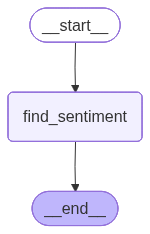

In [19]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment',find_sentiment)
graph.add_conditional_edges('find_sentiment',condition_check)

graph.add_edge(START, 'find_sentiment')
graph.add_edge('find_sentiment',END)
#graph.add_edge()

workflow = graph.compile()
workflow

In [ ]:
initial_state ={
    'review': "This product is very good"u87i8u87
}

workflow.invoke(initial_state)

Task find_sentiment with path ('__pregel_pull', 'find_sentiment') wrote to unknown channel branch:to:positive response, ignoring it.


{'review': 'This product is very good', 'sentiment': 'positive'}